In [6]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

### Basics

#### load mesh

In [7]:
# Load mesh or point cloud
mesh = o3d.io.read_triangle_mesh("../ply_files/output/output1_diff1.ply")  # For mesh
point_cloud = o3d.io.read_point_cloud("../ply_files/output/output1_diff1.ply")  # For point cloud

print("Mesh loaded:", mesh)
print("Point cloud loaded:", point_cloud)

[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
Mesh loaded: TriangleMesh with 11329 points and 0 triangles.
Point cloud loaded: PointCloud with 11329 points.


#### Visualize mesh

In [8]:
# Visualize mesh
o3d.visualization.draw_geometries([mesh], window_name="3D Mesh")

# Visualize point cloud
o3d.visualization.draw_geometries([point_cloud], window_name="Point Cloud")

[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.


In [9]:
# For Mesh
if mesh.has_vertices():
    print("Vertices:", np.asarray(mesh.vertices).shape)
if mesh.has_triangles():
    print("Triangles:", np.asarray(mesh.triangles).shape)

# For Point Cloud
if point_cloud.has_points():
    print("Points:", np.asarray(point_cloud.points).shape)
if point_cloud.has_colors():
    print("Colors:", np.asarray(point_cloud.colors).shape)

Vertices: (11329, 3)
Points: (11329, 3)


#### Downsample

In [10]:
downsampled = point_cloud.voxel_down_sample(voxel_size=0.05)
o3d.visualization.draw_geometries([downsampled], window_name="Downsampled Point Cloud")

#### Compute normals

In [11]:
# For Point Cloud
point_cloud.estimate_normals()
o3d.visualization.draw_geometries([point_cloud], window_name="Point Cloud with Normals")

# For Mesh
mesh.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh], window_name="Mesh with Normals")

[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.


In [12]:
# Define a bounding box (min and max bounds)
bbox = o3d.geometry.AxisAlignedBoundingBox(min_bound=(-1, -1, -1), max_bound=(1, 1, 1))
cropped_mesh = mesh.crop(bbox)
o3d.visualization.draw_geometries([cropped_mesh], window_name="Cropped Mesh")

[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.


In [9]:
o3d.io.write_triangle_mesh("../ply_files/processed_mesh.ply", mesh)
o3d.io.write_point_cloud("../ply_files/processed_points.ply", point_cloud)
print("Saved processed files!")

Saved processed files!


####  Mesh from point cloud (with normals)

Built in function
* does not work

In [10]:
# Only works if point cloud has normals
mesh_reconstructed, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(point_cloud, depth=10)
o3d.visualization.draw_geometries([mesh_reconstructed], window_name="Reconstructed Mesh")

Estimate normals function
* Process point cloud normal before creating mesh form point cloud
* this also does not estimate normals well. Need to do preprocessing

In [14]:
import open3d as o3d
import numpy as np

# Load point cloud
pcd = o3d.io.read_point_cloud("ply_files/full_tsdf_layer0_tsdf0_cleaned.ply")
pcd = point_cloud
# Estimate normals (key parameters)
pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=0.1,  # Search radius
        max_nn=30     # Max neighbors
    ),
    fast_normal_computation=True
)

# Optional: Orient normals consistently
pcd.orient_normals_to_align_with_direction(orientation_reference=[0, 0, 1])

# Visualize with normals
o3d.visualization.draw_geometries([pcd], point_show_normal=True)

# Access normals as numpy array
normals = np.asarray(pcd.normals)
print(f"Normals shape: {normals.shape}")
print(f"First normal: {normals[0]}")

[Open3D WARNING] Read PLY failed: unable to open file: ply_files\full_tsdf_layer0_tsdf0_cleaned.ply
Normals shape: (11329, 3)
First normal: [0. 0. 1.]


### Compute normal

In [179]:
##### Load point cloud
# ----tsdf output point cloud----
pcd = o3d.io.read_point_cloud("ply_files/reconstructed/full_tsdf_layer0_tsdf0_cleaned.ply")
# cd = o3d.io.read_point_cloud("ply_files/reconstructed/pc_layer0_2025-07-07-10-07.ply")
pcd = o3d.io.read_point_cloud("ply_files/reconstructed/pc_layer0_2025-07-21-01-59.ply")
pcd = o3d.io.read_point_cloud("ply_files/test ply inputs/hourglass_closed.ply")

# ----scatter algorithm output point cloud----
pcd = o3d.io.read_point_cloud("ply_files/output/output_stomach_1.ply")
pcd = o3d.io.read_point_cloud("ply_files/output/output_stomach_2.ply")
# pcd = o3d.io.read_point_cloud("ply_files/output/output_stomach_3.ply")

# pcd = o3d.io.read_point_cloud("ply_files/output/output_snail_6000.ply")
# pcd = o3d.io.read_point_cloud("ply_files/output/output_hourglass_closed.ply")
# pcd = o3d.io.read_point_cloud("ply_files/output/output_hourglass_opened.ply")
# pcd = o3d.io.read_point_cloud("../ply_files/output/output1_diff1.ply")

# pcd = o3d.io.read_point_cloud("ply_files/test ply inputs/snail.ply")

##### set processed file name (to ../normal_processed)
processed_file_name = "processed_stomach_2_pcd.ply"
# processed_file_name = "temp.ply"

In [180]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("C:\\Users\\ASUS\\OneDrive - HKUST Connect\\1_Projects\\ASTRI\\Project folder\\Hole detection")
print(os.getcwd())


print(f"Original point cloud: {len(pcd.points)} points")

# o3d.visualization.draw_geometries([pcd], point_show_normal=True, 
#                                  window_name="Final Normals")


# 1. Noise Reduction: Statistical Outlier Removal
print("\n=== Noise Reduction ===")
cl, ind = pcd.remove_statistical_outlier(nb_neighbors=50, std_ratio=2.0)
noisy_pcd = pcd.select_by_index(ind, invert=True)
clean_pcd = pcd.select_by_index(ind)

print(f"Removed {len(noisy_pcd.points)} noisy points")
print(f"Clean points remaining: {len(clean_pcd.points)}")

# Visualize noise removal
noisy_pcd.paint_uniform_color([1, 0, 0])  # Red = noise
clean_pcd.paint_uniform_color([0.6, 0.6, 0.6])  # Gray = clean
# o3d.visualization.draw_geometries([clean_pcd, noisy_pcd], window_name="Noise Removal")

# 2. Curvature-Adaptive Normal Estimation
print("\n=== Curvature-Adaptive Normal Estimation ===")

# Pre-compute curvature estimates
clean_pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=5)
)
curvatures = np.asarray(clean_pcd.compute_point_cloud_distance(clean_pcd))

# Adaptive neighborhood sizing based on curvature
def adaptive_normal_estimation(pcd, curvatures):
    points = np.asarray(pcd.points)
    normals = np.zeros_like(points)
    
    # Build KDTree for efficient neighborhood queries
    kdtree = o3d.geometry.KDTreeFlann(pcd)
    
    for i, point in enumerate(points):
        # Determine neighborhood size based on curvature
        curvature = curvatures[i]
        
        # High curvature = smaller neighborhood (preserve edges)
        if curvature > np.percentile(curvatures, 85):
            radius = 0.02
            max_nn = 15
        # Low curvature = larger neighborhood (smooth surfaces)
        elif curvature < np.percentile(curvatures, 15):
            radius = 0.1
            max_nn = 100
        # Medium curvature = balanced parameters
        else:
            radius = 0.05
            max_nn = 30
        
        # Find neighbors with adaptive parameters
        [k, idx, _] = kdtree.search_hybrid_vector_3d(point, radius, max_nn)
        
        if k < 3:
            # Fallback to minimum neighborhood
            [k, idx, _] = kdtree.search_knn_vector_3d(point, 3)
        
        # PCA for normal estimation
        neighbors = points[idx]
        covariance = np.cov(neighbors.T)
        _, eigenvectors = np.linalg.eigh(covariance)
        normals[i] = eigenvectors[:,0]  # Smallest eigenvalue
    
    return normals

# Compute normals with adaptive approach
adaptive_normals = adaptive_normal_estimation(clean_pcd, curvatures)
clean_pcd.normals = o3d.utility.Vector3dVector(adaptive_normals)

# 3. Edge-Aware Normal Refinement
print("\n=== Edge-Aware Refinement ===")

# Detect edges using normal variation
def detect_edges(pcd, threshold=30):
    points = np.asarray(pcd.points)
    normals = np.asarray(pcd.normals)
    edges = np.zeros(len(points), dtype=bool)
    
    kdtree = o3d.geometry.KDTreeFlann(pcd)
    
    for i, point in enumerate(points):
        [k, idx, _] = kdtree.search_knn_vector_3d(point, 20)
        if k < 3: continue
            
        # Calculate normal variation in neighborhood
        neighborhood_normals = normals[idx]
        mean_normal = neighborhood_normals.mean(axis=0)
        angular_diff = np.arccos(np.clip(np.dot(normals[i], mean_normal), -1, 1))
        angular_diff_deg = np.degrees(angular_diff)
        
        if angular_diff_deg > threshold:
            edges[i] = True
    
    return edges

edge_mask = detect_edges(clean_pcd)
edge_pcd = clean_pcd.select_by_index(np.where(edge_mask)[0])
non_edge_pcd = clean_pcd.select_by_index(np.where(~edge_mask)[0])

print(f"Detected {np.sum(edge_mask)} edge points")

# Visualize results
edge_pcd.paint_uniform_color([1, 0, 0])  # Red = edges
non_edge_pcd.paint_uniform_color([0, 0.8, 0.2])  # Green = non-edges
# o3d.visualization.draw_geometries([edge_pcd, non_edge_pcd], window_name="Edge Detection")

# 4. Final Normal Orientation
clean_pcd.orient_normals_towards_camera_location()
clean_pcd.orient_normals_consistent_tangent_plane(k=15)

# Save processed results
save_file = f"./ply_files/normal_processed/{processed_file_name}"
print(f"saving results to {save_file}")
o3d.io.write_point_cloud(f"{save_file}", clean_pcd) #___________________________________________________________________________________

# Visualization with normals
print("\n=== Final Result ===")
o3d.visualization.draw_geometries([clean_pcd], point_show_normal=True, 
                                  window_name="Final Normals")

# Curvature visualization
curvature_colors = plt.cm.jet(curvatures / curvatures.max())[:, :3]
clean_pcd.colors = o3d.utility.Vector3dVector(curvature_colors)
o3d.visualization.draw_geometries([clean_pcd], window_name="Curvature Map")

C:\Users\ASUS\OneDrive - HKUST Connect\1_Projects\ASTRI\Project folder\Hole detection
Original point cloud: 27575 points

=== Noise Reduction ===
Removed 728 noisy points
Clean points remaining: 26847

=== Curvature-Adaptive Normal Estimation ===

=== Edge-Aware Refinement ===
Detected 19981 edge points
saving results to ./ply_files/normal_processed/processed_stomach_2_pcd.ply

=== Final Result ===


C:\Users\ASUS\AppData\Local\Temp\ipykernel_39268\1785199916.py:134: RuntimeWarning: invalid value encountered in divide
  curvature_colors = plt.cm.jet(curvatures / curvatures.max())[:, :3]


# Point cloud to single layer Mesh

* the pcd here is now processed to be a single layer point cloud

In [183]:
pcf_file = "./ply_files/normal_processed/processed_stomach_1_pcd.ply"
pcf_file = "./ply_files/normal_processed/processed_stomach_2_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_stomach_3_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_snail_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_hourglass_closed_pcd.ply"


# pcf_file = "./ply_files/normal_processed/processed_stomach_1_raw_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_stomach_2_raw_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_stomach_3_raw_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_snail_raw_pcd.ply"
# pcf_file = "./ply_files/normal_processed/processed_hourglass_closed_raw_pcd.ply"

clean_pcd = o3d.io.read_point_cloud(pcf_file)

### Poisson mehtod

In [184]:
### 5. Mesh Reconstruction from Point Cloud with Normals ###
print("\n=== Mesh Reconstruction ===")

# Option A: Poisson Surface Reconstruction (best for watertight surfaces)
poisson_mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    clean_pcd, 
    depth=8,  # Reconstruction depth (8-12)
    width=0,  # Auto width
    scale=1.1,
    linear_fit=False
)

# Remove low-density vertices (optional)
vertices_to_remove = densities < np.quantile(densities, 0.01)
poisson_mesh.remove_vertices_by_mask(vertices_to_remove)

"""# Option B: Ball Pivoting (better for sharp features)
distances = clean_pcd.compute_nearest_neighbor_distance()
avg_dist = np.mean(distances)
radii = [avg_dist*1.5, avg_dist*2.0, avg_dist*3.0]
bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
    clean_pcd,
    o3d.utility.DoubleVector(radii)
)"""

# Smooth the mesh (optional)
mesh = poisson_mesh  # or bpa_mesh
mesh = mesh.filter_smooth_taubin(number_of_iterations=10)
mesh.compute_vertex_normals()

### Visualization ### ___________________________________________________
print("Visualizing reconstructed mesh...")
# o3d.visualization.draw_geometries([mesh], window_name="Reconstructed Mesh")

# Create a visualization with both point cloud and mesh
pcd_for_vis = clean_pcd
pcd_for_vis.paint_uniform_color([0.5, 0.5, 0.5])  # Gray points
mesh_for_vis = mesh
mesh_for_vis.paint_uniform_color([0.7, 0.3, 0.1])  # Orange mesh
mesh_for_vis.compute_vertex_normals()

# Compare side by side
o3d.visualization.draw_geometries([pcd_for_vis, mesh_for_vis], window_name="Point Cloud vs Mesh")

### Save Results ###
o3d.io.write_triangle_mesh("./ply_files/temp/ball_pivoting_mesh_.ply", mesh)  # PLY format
# o3d.io.write_triangle_mesh("reconstructed_mesh.obj", mesh)  # OBJ format
# o3d.io.write_triangle_mesh("./ply_files/reconstructed_mesh.stl", mesh)  # STL format
print("Saved reconstructed mesh as: ./temp/poisson_mesh_.ply")

# Save mesh with vertex colors (if needed)
mesh.vertex_colors = o3d.utility.Vector3dVector(
    np.tile([0.7, 0.3, 0.1], (len(mesh.vertices), 1))  # Orange color
)
# o3d.io.write_triangle_mesh("../ply_files/temp/colored_mesh.ply", mesh)

print("\n=== Process Complete ===")


=== Mesh Reconstruction ===
Visualizing reconstructed mesh...
Saved reconstructed mesh as: ./temp/poisson_mesh_.ply

=== Process Complete ===


### k mean + poisson method

In [189]:
import open3d as o3d
import numpy as np
from sklearn.cluster import KMeans

def extract_inner_layer(clean_pcd):
    # Convert to numpy arrays
    points = np.asarray(clean_pcd.points)
    normals = np.asarray(clean_pcd.normals)
    
    # Compute centroid
    centroid = np.mean(points, axis=0)
    
    # Calculate vectors from centroid to points
    vectors = points - centroid
    
    # Calculate dot products between vectors and normals
    # This indicates whether normals point toward or away from centroid
    dots = np.sum(vectors * normals, axis=1)
    
    # Cluster based on dot products to separate layers
    kmeans = KMeans(n_clusters=2, random_state=0).fit(dots.reshape(-1, 1))
    labels = kmeans.labels_
    
    # Determine which cluster is inner layer (should have negative dot products)
    cluster_means = [np.mean(dots[labels == 0]), np.mean(dots[labels == 1])]
    inner_label = 0 if cluster_means[0] < cluster_means[1] else 1
    
    # Select inner layer points
    inner_indices = np.where(labels == inner_label)[0]
    inner_pcd = clean_pcd.select_by_index(inner_indices)
    
    return inner_pcd, inner_indices

# Re-estimate normals with proper parameters
clean_pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(
        radius=0.05,  # Increase if large areas are missing
        max_nn=50     # Use more neighbors for smoother normals
    )
)
clean_pcd.orient_normals_towards_camera_location()  # Or use consistent tangent plane

o3d.visualization.draw_geometries([clean_pcd], point_show_normal=True, 
                                  window_name="Final Normals")

# Extract inner layer
inner_pcd, inner_indices = extract_inner_layer(clean_pcd)

# Optional: Visualize the separated layers
outer_pcd = clean_pcd.select_by_index(np.setdiff1d(range(len(clean_pcd.points)), inner_indices))
inner_pcd.paint_uniform_color([1, 0, 0])  # Red - inner layer
outer_pcd.paint_uniform_color([0, 0, 1])  # Blue - outer layer
o3d.visualization.draw_geometries([inner_pcd, outer_pcd])

# Now reconstruct mesh from inner layer only
print("\n=== Mesh Reconstruction from Inner Layer ===")
poisson_mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    inner_pcd, 
    depth=9,
    width=0,
    scale=1.1,
    linear_fit=False
)

# Remove low-density vertices
vertices_to_remove = densities < np.quantile(densities, 0.01)
poisson_mesh.remove_vertices_by_mask(vertices_to_remove)

# Smooth the mesh
mesh = poisson_mesh.filter_smooth_taubin(number_of_iterations=10)
mesh.compute_vertex_normals()

# Visualize and save
o3d.visualization.draw_geometries(
    [mesh],
    window_name="Inner Layer Mesh",
    width=800,
    height=600,
    mesh_show_wireframe=True,  # Show wireframe
    mesh_show_back_face=True  # Don't show back faces
)
o3d.io.write_triangle_mesh("./ply_files/temp/k_mean_mesh.ply", mesh)


=== Mesh Reconstruction from Inner Layer ===
[Open3D WARNING] Write Ply clamped color value to valid range


True

### Ball pivot + DBSCAN method

In [ ]:
import open3d as o3d
import numpy as np

def extract_inner_layer_and_convert_to_mesh(clean_pcd, output_path):
    # Load the point cloud
    pcd = clean_pcd
    if not pcd.has_points():
        raise ValueError("Point cloud is empty")
    
    # Preprocess: remove NaN and infinite points
    pcd = pcd.remove_non_finite_points()
    points = np.asarray(pcd.points)
    if len(points) == 0:
        raise ValueError("Point cloud has no valid points after preprocessing")
    
    # Compute centroid and distances
    centroid = np.mean(points, axis=0)
    dists_to_centroid = np.linalg.norm(points - centroid, axis=1)
    overall_median_dist = np.median(dists_to_centroid)
    
    # Compute average nearest neighbor distance for DBSCAN
    nn_distances = np.array(pcd.compute_nearest_neighbor_distance())
    avg_nn_dist = np.mean(nn_distances)
    eps = 5 * avg_nn_dist
    min_points = 10
    
    # Perform DBSCAN clustering
    labels = np.array(pcd.cluster_dbscan(eps=eps, min_points=min_points, print_progress=True))
    unique_labels, counts = np.unique(labels[labels >= 0], return_counts=True)
    
    # Collect clusters with sufficient size
    inner_indices = []
    min_cluster_size = 100
    
    for label in unique_labels:
        mask = (labels == label)
        cluster_indices = np.where(mask)[0]
        if len(cluster_indices) < min_cluster_size:
            continue
        cluster_avg_dist = np.mean(dists_to_centroid[cluster_indices])
        if cluster_avg_dist < overall_median_dist*1.2:
            inner_indices.extend(cluster_indices)
    
    if not inner_indices:
        raise RuntimeError("No inner layer clusters found. Adjust parameters or check data.")
    
    inner_pcd = pcd.select_by_index(inner_indices)
    
    # Estimate normals for the inner layer
    inner_pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=avg_nn_dist * 2, max_nn=30)
    )
    o3d.visualization.draw_geometries([inner_pcd], point_show_normal=True, window_name="inner point cloud")

    #-----------------------------------------------------------------------------------------------------------------------
    # Reconstruct mesh using ball pivoting
    inner_nn_dists = np.array(inner_pcd.compute_nearest_neighbor_distance())
    inner_avg_nn_dist = np.mean(inner_nn_dists)
    radii = o3d.utility.DoubleVector([
        inner_avg_nn_dist * 1.5,
        inner_avg_nn_dist * 2,
        inner_avg_nn_dist * 4
    ])
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(inner_pcd, radii)
    # Visualize
    o3d.visualization.draw_geometries(
    [mesh],
    window_name="Inner Layer Mesh",
    width=800,
    height=600,
    mesh_show_wireframe=True,  # Show wireframe
    mesh_show_back_face=True  # Don't show back faces
)

    # Save the mesh
    o3d.io.write_triangle_mesh(output_path, mesh)

# Example usage
if __name__ == "__main__":
    extract_inner_layer_and_convert_to_mesh(clean_pcd, "./ply_files/temp/DBSCAN_mesh_.ply")

### Slice method

Processing Slices:  16%|█▌        | 16/100 [00:11<00:58,  1.43slice/s]


KeyboardInterrupt: 

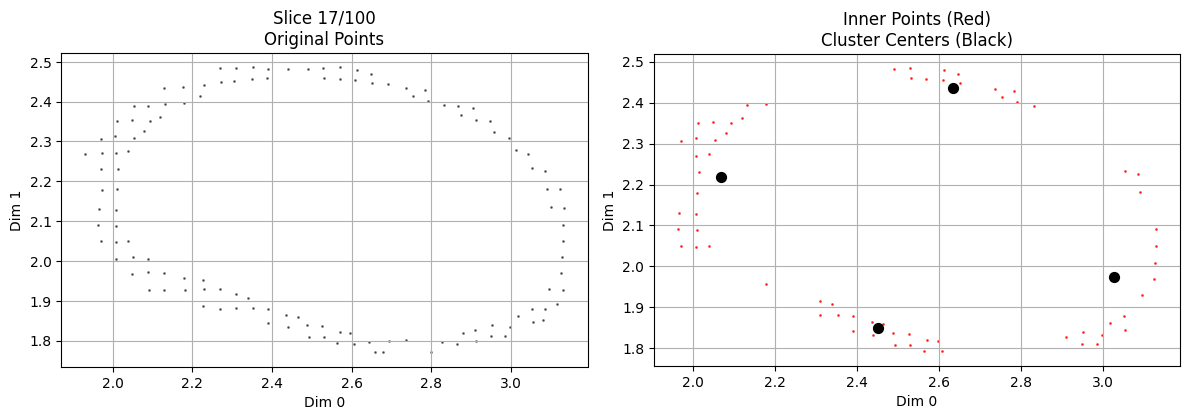

In [ ]:
import open3d as o3d
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Step 0: Configuration
PLY_FILE = ply_file
NUM_SLICES = 100
DOWN_SAMPLE_SIZE = 40000
SECTORS = 5
ANGLE_TOL = 5.0
ANALYSIS_DIR = "./analysis/pcd_layers_comparison"

# Create analysis directory
os.makedirs(ANALYSIS_DIR, exist_ok=True)

# Step 1: Preprocessing (same as before)
def preprocess_point_cloud(pcd):
    pcd.normals = o3d.utility.Vector3dVector(np.zeros((len(pcd.points), 3)))
    clean_pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    target_points = min(len(clean_pcd.points), DOWN_SAMPLE_SIZE)
    voxel_size = np.cbrt((clean_pcd.get_axis_aligned_bounding_box().volume() / target_points))
    down_pcd = clean_pcd.voxel_down_sample(voxel_size)
    points = np.asarray(down_pcd.points)
    if len(points) > DOWN_SAMPLE_SIZE:
        indices = np.random.choice(len(points), DOWN_SAMPLE_SIZE, replace=False)
        down_pcd.points = o3d.utility.Vector3dVector(points[indices])
    return down_pcd

def get_vertical_axis(points):
    ranges = np.ptp(points, axis=0)
    return np.argmax(ranges)

def get_slice_points(points, vertical_axis, min_val, max_val, slice_idx, num_slices):
    slice_height = (max_val - min_val) / num_slices
    z_low = min_val + slice_idx * slice_height - (0.1 * slice_height)
    z_high = z_low + slice_height + (0.2 * slice_height)
    in_slice = np.logical_and(points[:, vertical_axis] >= z_low,
                              points[:, vertical_axis] < z_high)
    return points[in_slice]

def process_slice(slice_points, vertical_axis, sector_counts):
    hor_axes = [i for i in range(3) if i != vertical_axis]
    inner_points = []
    valid_sectors = 0
    cluster_centers = []

    if len(slice_points) > 10:
        hor_points = slice_points[:, hor_axes]
        
        # K-means clustering
        best_k = 1
        if len(slice_points) > 1:
            best_k = min(4, len(slice_points))
            kmeans = KMeans(n_clusters=best_k, n_init=10).fit(hor_points)
            labels = kmeans.labels_
            cluster_centers = kmeans.cluster_centers_
            
            clusters = [slice_points[labels == i] for i in range(best_k)]
            
            for cluster_points in clusters:
                centroid = np.mean(cluster_points, axis=0)
                dx = cluster_points[:, hor_axes[0]] - centroid[hor_axes[0]]
                dy = cluster_points[:, hor_axes[1]] - centroid[hor_axes[1]]
                
                angles_rad = np.arctan2(dy, dx)
                angles_deg = (np.degrees(angles_rad) + 360) % 360
                sector_ids = np.clip((angles_deg / (360 / SECTORS)).astype(int), 0, SECTORS-1)
                radii = np.sqrt(dx**2 + dy**2)
                
                for sector in range(SECTORS):
                    in_sector = (sector_ids == sector)
                    sector_radii = radii[in_sector]
                    
                    if len(sector_radii) > 1:
                        try:
                            kmeans = KMeans(n_clusters=2, n_init=10).fit(sector_radii.reshape(-1,1))
                            inner_label = np.argmin(kmeans.cluster_centers_)
                            inner_mask = (kmeans.labels_ == inner_label)
                            inner_sector_points = cluster_points[in_sector][inner_mask]
                            inner_points.extend(inner_sector_points.tolist())
                            valid_sectors += 1
                        except Exception as e:
                            continue
                    elif len(sector_radii) == 1:
                        inner_points.append(cluster_points[in_sector][0])
    
    sector_counts.append(valid_sectors)
    return np.array(inner_points) if inner_points else np.zeros((0,3)), cluster_centers

# Step 4: Mesh reconstruction
def reconstruct_mesh(inner_points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(inner_points)
    
    # Estimate normals
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    
    # Ball pivoting reconstruction
    radii = [0.005, 0.01, 0.02, 0.04]
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd, o3d.utility.DoubleVector(radii))
    
    # Additional cleanup
    mesh.remove_duplicated_vertices()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()
    return mesh

def visualize_slice_comparison(slice_points, inner_points, cluster_centers, vertical_axis, slice_idx, total_slices):
    fig = plt.figure(figsize=(12, 6))
    hor_axes = [i for i in range(3) if i != vertical_axis]
    
    # Graph 1: Original slice points (black)
    ax1 = fig.add_subplot(121)
    if len(slice_points) > 0:
        ax1.scatter(slice_points[:, hor_axes[0]], 
                    slice_points[:, hor_axes[1]],
                    color='black', s=1, alpha=0.5)
    ax1.set_xlabel(f'Dim {hor_axes[0]}')
    ax1.set_ylabel(f'Dim {hor_axes[1]}')
    ax1.set_title(f'Slice {slice_idx+1}/{total_slices}\nOriginal Points')
    ax1.set_aspect('equal')
    ax1.grid(True)
    
    # Graph 2: Inner points (red) with cluster centers (big black dots)
    ax2 = fig.add_subplot(122)
    if len(inner_points) > 0:
        ax2.scatter(inner_points[:, hor_axes[0]], 
                    inner_points[:, hor_axes[1]],
                    color='red', s=1, alpha=0.7)
    
    # Plot cluster centers if they exist
    if len(cluster_centers) > 0:
        ax2.scatter(cluster_centers[:, 0], 
                    cluster_centers[:, 1],
                    color='black', s=50, marker='o')
    
    ax2.set_xlabel(f'Dim {hor_axes[0]}')
    ax2.set_ylabel(f'Dim {hor_axes[1]}')
    ax2.set_title('Inner Points (Red)\nCluster Centers (Black)')
    ax2.set_aspect('equal')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, f'slice_comp_{slice_idx:03d}.png'))
    plt.close(fig)

def main():
    # Load and preprocess
    processed_pcd = clean_pcd
    points = np.asarray(processed_pcd.points)
    
    # Vertical slicing setup
    vertical_axis = get_vertical_axis(points)
    v_min, v_max = np.min(points[:, vertical_axis]), np.max(points[:, vertical_axis])
    
    # Slice processing
    sector_counts = []
    all_inner_points = []
    
    for slice_idx in tqdm(range(NUM_SLICES), desc="Processing Slices", unit="slice"):
        slice_points = get_slice_points(points, vertical_axis, v_min, v_max, slice_idx, NUM_SLICES)
        
        if len(slice_points) > 3:
            inner_points, cluster_centers = process_slice(slice_points, vertical_axis, sector_counts)
            if len(inner_points) > 0:
                all_inner_points.append(inner_points)
            
            # Visualize comparison
            visualize_slice_comparison(slice_points, inner_points, cluster_centers, 
                                     vertical_axis, slice_idx, NUM_SLICES)
    
    # Rest of the processing remains unchanged
    inner_points_arr = np.vstack(all_inner_points)
    inner_points_arr = np.unique(inner_points_arr, axis=0)
    
    final_mesh = reconstruct_mesh(inner_points_arr)
    
    # Visualization and saving results
    inner_pcd = o3d.geometry.PointCloud()
    inner_pcd.points = o3d.utility.Vector3dVector(inner_points_arr)
    inner_pcd.paint_uniform_color([0, 1, 0])
    
    o3d.visualization.draw_geometries([inner_pcd], window_name="Inner Layer Point Cloud")
    o3d.visualization.draw_geometries([final_mesh], window_name="Reconstructed Mesh")
    
    # o3d.io.write_point_cloud("./ply_files/temp/slice_mesh_.ply", inner_pcd)
    o3d.io.write_triangle_mesh("./ply_files/temp/slice_mesh_.ply", final_mesh)

if __name__ == "__main__":
    main()

### slice + longest path method

In [4]:
import open3d as o3d
import numpy as np
from scipy.spatial import ConvexHull, distance_matrix
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import networkx as nx

# Configuration
PLY_FILE = "./ply_files/reconstructed/pc_layer0_2025-07-07-10-07.ply"
NUM_SLICES = 50
DOWN_SAMPLE_SIZE = 40000
ANALYSIS_DIR = "./analysis/pcd_layers"
os.makedirs(ANALYSIS_DIR, exist_ok=True)

# Preprocessing functions
def get_vertical_axis(points):
    ranges = np.ptp(points, axis=0)
    return np.argmax(ranges)

def preprocess_point_cloud(pcd):
    pcd.normals = o3d.utility.Vector3dVector(np.zeros((len(pcd.points), 3)))
    clean_pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    target_points = min(len(clean_pcd.points), DOWN_SAMPLE_SIZE)
    voxel_size = np.cbrt((clean_pcd.get_axis_aligned_bounding_box().volume() / target_points))
    down_pcd = clean_pcd.voxel_down_sample(voxel_size)
    points = np.asarray(down_pcd.points)
    if len(points) > DOWN_SAMPLE_SIZE:
        indices = np.random.choice(len(points), DOWN_SAMPLE_SIZE, replace=False)
        down_pcd.points = o3d.utility.Vector3dVector(points[indices])
    return down_pcd

def get_slice_points(points, vertical_axis, min_val, max_val, slice_idx, num_slices):
    slice_height = (max_val - min_val) / num_slices
    z_low = min_val + slice_idx * slice_height - (0.1 * slice_height)
    z_high = z_low + slice_height + (0.2 * slice_height)
    in_slice = np.logical_and(points[:, vertical_axis] >= z_low,
                              points[:, vertical_axis] < z_high)
    return points[in_slice]

# Create graph connections with k nearest neighbors
def create_graph_connections(slice_points_2d, k=3):
    # Convert 2D points to 3D (z=0) for KDTree compatibility
    points_3d = np.hstack([slice_points_2d, np.zeros((len(slice_points_2d), 1))])
    
    # Build KDTree
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d)
    kd_tree = o3d.geometry.KDTreeFlann(pcd)
    
    graph = {}
    n = len(slice_points_2d)
    
    # Calculate adaptive distance threshold using pairwise distances
    if n > 1:
        distances = distance_matrix(slice_points_2d, slice_points_2d)
        np.fill_diagonal(distances, np.inf)
        min_dists = np.min(distances, axis=1)
        mean_min_dist = np.mean(min_dists)
        distance_threshold = 3.0 * mean_min_dist
    else:
        distance_threshold = 0.0
    
    for i in range(n):
        [_, idxs, dists] = kd_tree.search_knn_vector_3d(points_3d[i], k+1)  # +1 to exclude self
        
        neighbors = []
        for j in range(1, len(idxs)):  # Skip self (first index is always self)
            idx = idxs[j]
            dist = dists[j]
            
            # Only include if within distance threshold
            if dist < distance_threshold:
                neighbors.append(idx)
                
        graph[i] = neighbors
        
    return graph

# Find longest cycle using graph theory
def find_longest_cycle(graph, slice_points_2d):
    if len(graph) < 3:
        return np.array([])  # Not enough points for a cycle
    
    try:
        # Create networkx graph
        G = nx.Graph()
        for node, neighbors in graph.items():
            for neighbor in neighbors:
                if neighbor in graph and node in graph[neighbor]:
                    G.add_edge(node, neighbor)
        
        # Get connected components and find largest
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc).copy()
        
        # Find cycles in the largest component
        cycles = nx.cycle_basis(subgraph)
        if not cycles:
            return np.array([])
        
        # Find longest cycle
        longest_cycle = max(cycles, key=len)
        return slice_points_2d[longest_cycle]
        
    except Exception as e:
        print(f"Cycle finding error: {e}")
        return np.array([])

# Mesh reconstruction
def reconstruct_mesh(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    
    # Alpha shape reconstruction (better for complex surfaces)
    tetra_mesh, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcd)
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, 0.1, tetra_mesh, pt_map)
    
    mesh.remove_duplicated_vertices()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()
    
    return mesh

# Visualization
def visualize_slice_comparison(slice_points, outer_points, slice_idx, total_slices):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Original slice
    ax1.scatter(slice_points[:, 0], slice_points[:, 1], s=3, c='black', alpha=0.6)
    ax1.set_title(f'Slice {slice_idx+1}/{total_slices}\nOriginal Points ({len(slice_points)})')
    ax1.set_aspect('equal')
    ax1.grid(True)
    
    # Detected outer points
    if len(outer_points) > 0:
        ax2.scatter(outer_points[:, 0], outer_points[:, 1], s=5, c='red')
        ax2.plot(np.append(outer_points[:, 0], outer_points[0, 0]), 
                 np.append(outer_points[:, 1], outer_points[0, 1]), 
                 'b-', linewidth=0.5)
    ax2.set_title(f'Outer Boundary ({len(outer_points)} points)')
    ax2.set_aspect('equal')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, f'slice_{slice_idx:03d}.png'), dpi=150)
    plt.close()

# Main processing
def main():
    # Load and preprocess point cloud
    pcd = o3d.io.read_point_cloud(PLY_FILE)
    processed_pcd = preprocess_point_cloud(pcd)
    points = np.asarray(processed_pcd.points)
    
    # Get vertical axis and slice parameters
    vertical_axis = get_vertical_axis(points)
    hor_axes = [i for i in range(3) if i != vertical_axis]
    v_min, v_max = np.min(points[:, vertical_axis]), np.max(points[:, vertical_axis])
    
    # Store outer points for mesh reconstruction
    all_outer_points = []
    
    # Process each slice
    for slice_idx in tqdm(range(NUM_SLICES), desc="Processing Slices"):
        # Get points in current slice
        slice_points = get_slice_points(points, vertical_axis, v_min, v_max, slice_idx, NUM_SLICES)
        
        if len(slice_points) < 3:
            continue
            
        # Convert to 2D for processing
        slice_points_2d = slice_points[:, hor_axes]
        z_value = np.mean(slice_points[:, vertical_axis])
        
        # Create graph with nearest neighbors
        graph = create_graph_connections(slice_points_2d)
        
        # Find outer boundary using graph theory
        outer_points_2d = find_longest_cycle(graph, slice_points_2d)
        
        # Fallback to convex hull if no valid boundary found
        if len(outer_points_2d) == 0:
            if len(slice_points_2d) >= 3:
                hull = ConvexHull(slice_points_2d)
                outer_points_2d = slice_points_2d[hull.vertices]
        
        # Convert to 3D (add z value)
        if len(outer_points_2d) > 0:
            outer_points_3d = np.zeros((len(outer_points_2d), 3))
            outer_points_3d[:, hor_axes] = outer_points_2d
            outer_points_3d[:, vertical_axis] = z_value
            
            # Save for mesh reconstruction
            all_outer_points.append(outer_points_3d)
        
        # Visualize and save comparison
        visualize_slice_comparison(slice_points_2d, outer_points_2d, slice_idx, NUM_SLICES)
    
    # Reconstruct mesh from outer points
    if len(all_outer_points) > 0:
        outer_points_arr = np.vstack(all_outer_points)
        
        # Save outer points
        outer_pcd = o3d.geometry.PointCloud()
        outer_pcd.points = o3d.utility.Vector3dVector(outer_points_arr)
        o3d.io.write_point_cloud("outer_layer.ply", outer_pcd)
        
        # Reconstruct and visualize mesh
        final_mesh = reconstruct_mesh(outer_points_arr)
        o3d.io.write_triangle_mesh("stomach_mesh_outer.ply", final_mesh)
        
        # Visualize final results
        o3d.visualization.draw_geometries([final_mesh], window_name="Reconstructed Outer Mesh")
    else:
        print("No outer points detected. Unable to reconstruct mesh.")

if __name__ == "__main__":
    main()

Processing Slices: 100%|██████████| 50/50 [00:18<00:00,  2.73it/s]
